In this notebook Seamese network model for handwriting author verification with triplet loss trained. As backup vit_base_patch16_224 model used.

Importing training dataset

In [1]:
#importing dataset
!pip install -q gdown

file_id = "1xpXGz2iJ7VhRG7iSZptX7V5v4dALLhvl"
output_name = "all_data_3.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1xpXGz2iJ7VhRG7iSZptX7V5v4dALLhvl
From (redirected): https://drive.google.com/uc?id=1xpXGz2iJ7VhRG7iSZptX7V5v4dALLhvl&confirm=t&uuid=c0e62635-ccda-48d4-bb06-713af87f7a88
To: /kaggle/working/all_data_3.zip
100%|███████████████████████████████████████| 1.76G/1.76G [00:17<00:00, 100MB/s]


In [2]:
import zipfile
import os

with zipfile.ZipFile("all_data_3.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

# Посмотрите, что получилось
os.listdir("/kaggle/working/")

['all_data_3.zip', '.virtual_documents', 'all_data_3']

In [3]:
DATA_ROOT = "/kaggle/working/all_data_3"

Importing .pkl files with validation anf test data

In [4]:
val_dataset_file="1aJ87RzaTUVQcC8CIT_7xiPWQGFn0pAOx"
output_name = "val_triplet.pkl"

!gdown --id {val_dataset_file} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1aJ87RzaTUVQcC8CIT_7xiPWQGFn0pAOx
To: /kaggle/working/val_triplet.pkl
100%|████████████████████████████████████████| 178k/178k [00:00<00:00, 78.5MB/s]


In [25]:
test_dataset_file="17eaXxFbrPBEg0qoVBHP3ryICsLJo9hIF"
output_name = "test_pairs.pkl"

!gdown --id {test_dataset_file} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=17eaXxFbrPBEg0qoVBHP3ryICsLJo9hIF
To: /kaggle/working/test_pairs.pkl
100%|██████████████████████████████████████| 95.7k/95.7k [00:00<00:00, 52.4MB/s]


In [27]:
DATA_ROOT_val_pairs = "/kaggle/working/val_triplet.pkl"
DATA_ROOT_test_pairs = "/kaggle/working/test_pairs.pkl"

Importing required modules

In [7]:
!pip install torchvision

In [8]:
!pip install timm

In [9]:
import os
from pathlib import Path
import cv2
import numpy as np
import shutil
import random
import torch

from torch.utils.data import Dataset
import PIL
from PIL import Image
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader

import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import timm
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
import pickle


Fixing seeds

In [10]:
def set_seed(seed=42):
    """Fix all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"All seeds fixed to {seed}")
set_seed(42)

All seeds fixed to 42


Now let's creating TripletDataset class which takes root to folder with training domain and creates triplets 
This dataset implements triplet sampling for handwriting verification across multiple datasets (IAM, CEDAR, Bengali, Hindi).

What it does:
Generates triplets (anchor, positive, negative) for training a Siamese network with triplet loss.

How it works:
Two sampling strategies (controlled by iam_ratio):

IAM dataset (handwriting lines) - iam_ratio=0.5 (50% of samples):

Anchor & Positive: Two different handwritten samples from the SAME author

Negative: A sample from a DIFFERENT author

Signature datasets (CEDAR, Bengali, Hindi):

Anchor & Positive: Two genuine signatures from the SAME author

Negative: A FORGERY of the same author (skilled forgery)

Key features:
Automatically scans folder structures for each dataset

Validates images before loading

Supports train/validation split via authors_list parameter

Falls back to available data if primary sampling fails

Returns 3 augmented images ready for triplet loss training

Typical output shape:
(anchor, positive, negative) where each is a tensor [C, H, W] (grayscale, transformed).

In [11]:
class TripletDataset(Dataset):
    def __init__(self, root, transform=None, size=100,
                 authors_list=None, iam_ratio=0.5):
        """
        Dataset for Triplet Loss.
        Supports IAM (handwriting lines), CEDAR, Bengali, Hindi (signatures with forgeries).

        Returns triplets (anchor, positive, negative) where:
        - IAM: anchor + positive = same author, negative = different author
        - Signature datasets: anchor + positive = two genuine of same author, negative = forgery of same author

        Args:
            root: Root directory containing 'iam', 'cedar', 'bengali', 'hindi' folders
            transform: Image transformations
            size: Number of triplets per epoch
            authors_list: List of author IDs to include (for train/val split)
            iam_ratio: Probability of sampling from IAM (0.5 = 50% IAM)
        """
        self.transform = transform
        self.size = size
        self.iam_ratio = iam_ratio

        # Data structures
        self.iam_data = {}
        self.cedar_original = {}
        self.cedar_forgery = {}
        self.bengali_original = {}
        self.bengali_forgery = {}
        self.hindi_original = {}
        self.hindi_forgery = {}

        #Scan IAM folder
        iam_path = os.path.join(root, 'iam')
        if os.path.exists(iam_path):
            for folder in os.listdir(iam_path):
                author_path = os.path.join(iam_path, folder)
                if not os.path.isdir(author_path):
                    continue

                author_id = folder
                valid_images = []
                for file in os.listdir(author_path):
                    if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        continue

                    img_path = os.path.join(author_path, file)
                    try:
                        with Image.open(img_path) as img:
                            img.verify()
                        valid_images.append(img_path)
                    except Exception:
                        continue

                if valid_images:
                    self.iam_data[author_id] = valid_images

        #Scan CEDAR folder
        cedar_path = os.path.join(root, 'cedar')
        if os.path.exists(cedar_path):
            cedar_original_path = os.path.join(cedar_path, 'original')
            if os.path.exists(cedar_original_path):
                for author_id in os.listdir(cedar_original_path):
                    author_path = os.path.join(cedar_original_path, author_id)
                    if not os.path.isdir(author_path):
                        continue

                    valid_images = []
                    for file in os.listdir(author_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(author_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue

                    if valid_images:
                        self.cedar_original[author_id] = valid_images

            cedar_forgery_path = os.path.join(cedar_path, 'forgery')
            if os.path.exists(cedar_forgery_path):
                for author_id in os.listdir(cedar_forgery_path):
                    author_path = os.path.join(cedar_forgery_path, author_id)
                    if not os.path.isdir(author_path):
                        continue

                    valid_images = []
                    for file in os.listdir(author_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(author_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue

                    if valid_images:
                        self.cedar_forgery[author_id] = valid_images

        #Scan Bengali folder
        bengali_path = os.path.join(root, 'bengali')
        if os.path.exists(bengali_path):
            for author_id in os.listdir(bengali_path):
                author_path = os.path.join(bengali_path, author_id)
                if not os.path.isdir(author_path):
                    continue

                genuine_path = os.path.join(author_path, 'genuine')
                if os.path.exists(genuine_path):
                    valid_images = []
                    for file in os.listdir(genuine_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(genuine_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.bengali_original[author_id] = valid_images

                forge_path = os.path.join(author_path, 'forge')
                if os.path.exists(forge_path):
                    valid_images = []
                    for file in os.listdir(forge_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(forge_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.bengali_forgery[author_id] = valid_images

        #Scan Hindi folder
        hindi_path = os.path.join(root, 'hindi')
        if os.path.exists(hindi_path):
            for author_id in os.listdir(hindi_path):
                author_path = os.path.join(hindi_path, author_id)
                if not os.path.isdir(author_path):
                    continue

                genuine_path = os.path.join(author_path, 'genuine')
                if os.path.exists(genuine_path):
                    valid_images = []
                    for file in os.listdir(genuine_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(genuine_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.hindi_original[author_id] = valid_images

                forge_path = os.path.join(author_path, 'forge')
                if os.path.exists(forge_path):
                    valid_images = []
                    for file in os.listdir(forge_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(forge_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.hindi_forgery[author_id] = valid_images

        # Filter by authors_list if provided
        if authors_list is not None:
            author_set = set(authors_list)
            self.iam_data = {k: v for k, v in self.iam_data.items() if k in author_set}
            self.cedar_original = {k: v for k, v in self.cedar_original.items() if k in author_set}
            self.cedar_forgery = {k: v for k, v in self.cedar_forgery.items() if k in author_set}
            self.bengali_original = {k: v for k, v in self.bengali_original.items() if k in author_set}
            self.bengali_forgery = {k: v for k, v in self.bengali_forgery.items() if k in author_set}
            self.hindi_original = {k: v for k, v in self.hindi_original.items() if k in author_set}
            self.hindi_forgery = {k: v for k, v in self.hindi_forgery.items() if k in author_set}

        # Build author lists
        self.iam_authors = [a for a, imgs in self.iam_data.items() if len(imgs) >= 2]
        self.iam_all_authors = list(self.iam_data.keys())

        def build_signature_lists(original_dict, forgery_dict):
            authors_with_original = [a for a, imgs in original_dict.items() if len(imgs) >= 2]
            authors_with_forgery = [a for a in original_dict.keys()
                                     if a in forgery_dict
                                     and len(original_dict[a]) >= 1
                                     and len(forgery_dict[a]) >= 1]
            all_authors = list(original_dict.keys())
            return authors_with_original, authors_with_forgery, all_authors

        self.cedar_authors, self.cedar_authors_with_forgery, self.cedar_all_authors = build_signature_lists(self.cedar_original, self.cedar_forgery)
        self.bengali_authors, self.bengali_authors_with_forgery, self.bengali_all_authors = build_signature_lists(self.bengali_original, self.bengali_forgery)
        self.hindi_authors, self.hindi_authors_with_forgery, self.hindi_all_authors = build_signature_lists(self.hindi_original, self.hindi_forgery)

        # Combine signature datasets
        self.signature_datasets = []
        if self.cedar_authors or self.cedar_authors_with_forgery:
            self.signature_datasets.append(('cedar', self.cedar_original, self.cedar_forgery,
                                           self.cedar_authors, self.cedar_authors_with_forgery, self.cedar_all_authors))
        if self.bengali_authors or self.bengali_authors_with_forgery:
            self.signature_datasets.append(('bengali', self.bengali_original, self.bengali_forgery,
                                           self.bengali_authors, self.bengali_authors_with_forgery, self.bengali_all_authors))
        if self.hindi_authors or self.hindi_authors_with_forgery:
            self.signature_datasets.append(('hindi', self.hindi_original, self.hindi_forgery,
                                           self.hindi_authors, self.hindi_authors_with_forgery, self.hindi_all_authors))

    def __len__(self):
        return self.size

    def _get_iam_triplet(self):
        """IAM triplet: anchor + positive = same author, negative = different author"""
        if len(self.iam_authors) < 1:
            return None, None, None

        author = random.choice(self.iam_authors)
        images = self.iam_data[author]
        if len(images) < 2:
            return None, None, None

        # Anchor and Positive: two different images from same author
        anchor_path, positive_path = random.sample(images, 2)

        # Negative: different author
        other_authors = [a for a in self.iam_all_authors if a != author]
        if not other_authors:
            return None, None, None

        negative_author = random.choice(other_authors)
        negative_path = random.choice(self.iam_data[negative_author])

        return anchor_path, positive_path, negative_path

    def _get_signature_triplet(self, original_dict, forgery_dict, authors_with_forgery):
        """Signature triplet: anchor + positive = two genuines of same author, negative = forgery of same author"""
        if not authors_with_forgery:
            return None, None, None

        author = random.choice(authors_with_forgery)
        original_images = original_dict[author]
        forgery_images = forgery_dict[author]

        if len(original_images) < 2 or not forgery_images:
            return None, None, None
        # Anchor and Positive: two different genuine images
        anchor_path, positive_path = random.sample(original_images, 2)

        # Negative: forgery of the same author
        negative_path = random.choice(forgery_images)

        return anchor_path, positive_path, negative_path

    def __getitem__(self, idx):
        use_iam = random.random() < self.iam_ratio

        anchor_path, positive_path, negative_path = None, None, None

        if use_iam and self.iam_authors:
            anchor_path, positive_path, negative_path = self._get_iam_triplet()

        if anchor_path is None and self.signature_datasets:
            dataset_name, original_dict, forgery_dict, authors, authors_with_forgery, all_authors = random.choice(self.signature_datasets)
            anchor_path, positive_path, negative_path= self._get_signature_triplet(original_dict, forgery_dict, authors_with_forgery)

        if anchor_path is None:
            # Fallback: try IAM
            if self.iam_authors:
                anchor_path, positive_path, negative_path = self._get_iam_triplet()
            elif self.signature_datasets:
                dataset_name, original_dict, forgery_dict, authors, authors_with_forgery, all_authors = random.choice(self.signature_datasets)
                anchor_path, positive_path, negative_path = self._get_signature_triplet(original_dict, forgery_dict, authors_with_forgery)

        # Load images
        anchor = Image.open(anchor_path).convert('L')
        positive = Image.open(positive_path).convert('L')
        negative = Image.open(negative_path).convert('L')

        if self.transform:
            anchor = self.transform(anchor)
            positive = self.transform(positive)
            negative = self.transform(negative)

        return anchor, positive, negative

In [12]:
train_authors=['353', '662', '546', '181', '126', '104', '15', '72', '629', '094', '10', '139', '090', '636', '160', '092', '136', '328', '190', '20', '392', '652',
               '5', '405', '378', '236', '650', '573', '162', '349', '515', '59', '128', '421', '48', '14', '3', '262', '454', '670', '281', '543', '435', '632', '393',
               '192', '594', '237', '270', '250', '153', '320', '6', '531', '418', '399', '460', '603', '027', '598', '276', '083', '216', '391', '131', '2', '496', '53',
               '618', '093', '318', '214', '189', '110', '425', '389', '420', '401', '32', '562', '170', '93', '609', '616', '357', '597', '80', '626', '332', '119', '060',
               '487', '025', '547', '390', '513', '147', '072', '553', '183', '623', '615', '500', '198', '011', '174', '647', '664', '278', '445', '290', '210', '272',
               '448', '503', '534', '69', '88', '68', '120', '24', '464', '398', '568', '070', '610', '628', '591', '31', '529', '215', '149', '138', '118', '451', '572',
               '17', '339', '049', '25', '60', '26', '243', '054', '032', '586', '471', '377', '342', '87', '58', '620', '179', '89', '109', '304', '034', '365', '373',
               '363', '169', '071', '49', '579', '382', '444', '412', '485', '310', '473', '619', '084', '518', '535', '144', '542', '280', '145', '520', '156', '099',
               '576', '570', '589', '059', '595', '208', '361', '307', '558', '101', '67', '030', '38', '115', '19', '371', '340', '567', '319', '352', '274', '530',
               '102', '259', '555', '525', '462', '226', '27', '539', '041', '607', '508', '344', '182', '79', '288', '085', '095', '239', '267', '584', '92', '639',
               '410', '70', '184', '121', '492', '114', '509', '053', '334', '246', '490', '449', '255', '440', '185', '580', '294', '477', '495', '436', '291', '641',
               '33', '35', '21', '089', '103', '289', '370', '221', '466', '242', '076', '423', '379', '020', '008', '224', '019', '248', '98', '067', '483', '37', '663',
               '064', '582', '086', '031', '23', '563', '611', '305', '96', '472', '283', '043', '414', '141', '34', '151', '065', '621', '55', '91', '260', '231', '048',
               '478', '499', '606', '056', '354', '229', '045', '81', '096', '343', '408', '264', '155', '596', '253', '461', '235', '042', '73', '347', '482', '475',
               '386', '197', '394', '431', '65', '634', '416', '90', '36', '303', '122', '018', '517', '668', '252', '097', '228', '107', '413', '082', '556', '203',
               '494', '285', '028', '191', '592', '256', '578', '171', '002', '188', '526', '367', '116', '522', '234', '71', '30', '035', '364', '268', '327', '484',
               '146', '312', '533', '4', '046', '209', '433', '86', '402', '350', '640', '428', '453', '279', '536', '441', '037', '614', '47', '296', '159', '315', '062',
               '000', '407', '549', '080', '335', '079', '504', '659', '419', '117', '540', '081', '452', '351', '521', '384', '051', '648', '524', '036', '411', '75',
               '645', '325', '559', '211', '583', '527', '1', '502', '447', '7', '193', '565', '99', '152', '551', '608', '403', '195', '298', '006', '004', '077',
               '187', '301', '491', '366', '130', '538', '206', '324', '175', '098', '247', '180', '222', '251', '28', '63', '474', '671', '545', '088', '052', '388',
               '257', '123', '172', '486', '83', '554', '41', '417', '430', '660', '023', '56', '380', '40', '227', '566', '026', '219', '481', '575', '309', '489', '638',
               '148', '45', '258', '249', '200', '356', '331', '263', '232', '630', '063', '164', '544', '168', '359', '443', '047', '186', '85', '470', '336', '176',
               '078', '651', '196', '577', '455', '012', '666', '571', '317', '376', '429', '655', '314', '52', '600', '058', '212', '016', '022', '217', '94', '106',
               '44', '244', '77', '199', '8', '329', '22', '519', '561', '643', '64', '137', '501', '493']
val_authors=['456', '9', '426', '97', '322', '133', '13', '021', '157', '355', '166', '375', '627', '345', '605', '140', '135', '161', '163', '593', '476', '84', '225',
             '223', '62', '213', '512', '266', '537', '446', '100', '346', '422', '233', '613', '167', '261', '360', '127', '633', '292', '442', '341', '564', '468',
             '654', '467', '302', '330', '220', '465', '458', '18', '299', '326', '286', '014', '528', '635', '007', '569', '548', '333', '57', '207', '581', '039',
             '50', '338', '439', '205', '54', '552', '173', '348', '644', '488', '665', '362', '498', '409', '637', '587', '075', '300', '108', '642', '74', '400',
             '76', '074', '125', '51', '091', '017', '295', '245', '624', '142', '383', '585', '457', '230', '040', '497', '073', '432', '369', '275', '506', '201',
             '241', '129', '218']
test_authors=['43', '134', '516', '055', '204', '313', '523', '068', '404', '372', '601', '395', '469', '617', '009', '254', '588', '194', '337', '178', '511', '29',
              '015', '82', '287', '124', '599', '112', '39', '541', '293', '010', '143', '625', '132', '95', '158', '649', '622', '316', '282', '667', '532', '321',
              '177', '013', '505', '297', '631', '42', '658', '66', '368', '202', '510', '590', '165', '459', '154', '434', '61', '005', '397', '105', '602', '265',
              '46', '396', '387', '450', '323', '001', '087', '240', '113', '066', '604', '044', '061', '550', '463', '653', '033', '273', '669', '514', '150', '024',
              '424', '479', '069', '16', '574', '308', '238', '038', '415', '560', '385', '557', '277', '480', '612', '661', '111', '12', '427', '78', '050', '003',
              '269', '11', '406', '029']


In [13]:
train_transform = T.Compose([
    T.Resize((224, 224)),  #use 224*224 for the model
    T.RandomRotation(3),
    T.RandomAffine(0, translate=(0.02, 0.02), scale=(0.98, 1.02)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

In [14]:
train_dataset = TripletDataset(
    root=DATA_ROOT,
    transform=train_transform,
    train=True,
    size=5000,
    authors_list=train_authors
)



TripletDataset initialized:
  IAM: 453 authors, 6772 images
  CEDAR: 35 authors, 840 genuine, 840 forgery
  Bengali: 74 authors
  Hindi: 114 authors
  IAM ratio: 50%


Now let's create val and test-pairs dataset

In [30]:
class SavedTestPairsDataset(Dataset):
    def __init__(self, pairs_file, transform=None):
        with open(pairs_file, 'rb') as f:
            self.pairs = pickle.load(f)
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_path, img2_path, label = self.pairs[idx]

        img1 = Image.open(img1_path).convert('L')
        img2 = Image.open(img2_path).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, label

# # Создание и сохранение
# val_pairs = []
# test_pairs = []
# temp_dataset_val = Pairs_Dataset(root=DATA_ROOT, transform=None, train=False,
#                               size=2000, authors_list=val_authors)
# temp_dataset_test = Pairs_Dataset(root=DATA_ROOT, transform=None, train=False,
#                               size=1000, authors_list=test_authors)
# for i in range(len(temp_dataset_val)):
#     img1, img2, label, p1, p2 = temp_dataset_val[i]
#     val_pairs.append((p1, p2, label))

# for i in range(len(temp_dataset_test)):
#     img1, img2, label, p1, p2 = temp_dataset_test[i]
#     test_pairs.append((p1, p2, label))

# with open('val_pairs.pkl', 'wb') as f:
#     pickle.dump(val_pairs, f)

# with open('test_pairs.pkl', 'wb') as f:
#     pickle.dump(test_pairs, f)

# Загрузка

test_dataset = SavedTestPairsDataset('test_pairs.pkl', transform=test_transform)

In [15]:
class SavedTripletsDataset(Dataset):
    def __init__(self, pairs_file, transform=None):
        with open(pairs_file, 'rb') as f:
            self.pairs = pickle.load(f)
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_path, img2_path, img3_path = self.pairs[idx]

        img1 = Image.open(img1_path).convert('L')
        img2 = Image.open(img2_path).convert('L')
        img3 = Image.open(img3_path).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)
            img3 = self.transform(img3)

        return img1, img2, img3

In [16]:

# val_pairs = []
# test_pairs = []
# temp_dataset_val = Pairs_Dataset(root=DATA_ROOT, transform=None, train=False,
#                               size=2000, authors_list=val_authors)
# temp_dataset_test = Pairs_Dataset(root=DATA_ROOT, transform=None, train=False,
#                               size=1000, authors_list=test_authors)
# for i in range(len(temp_dataset_val)):
#     img1, img2, label, p1, p2 = temp_dataset_val[i]
#     val_pairs.append((p1, p2, label))

# for i in range(len(temp_dataset_test)):
#     img1, img2, label, p1, p2 = temp_dataset_test[i]
#     test_pairs.append((p1, p2, label))

# with open('val_pairs.pkl', 'wb') as f:
#     pickle.dump(val_pairs, f)

# with open('test_pairs.pkl', 'wb') as f:
#     pickle.dump(test_pairs, f)

val_dataset = SavedTripletsDataset('val_triplet.pkl', transform=val_transform)

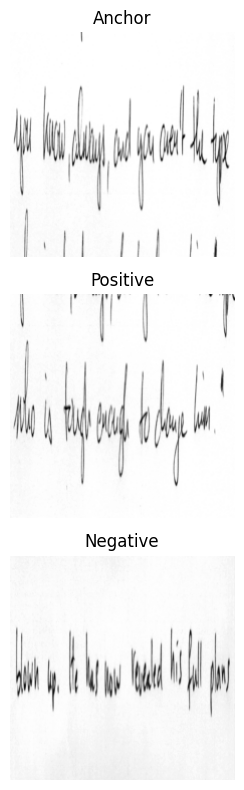

In [17]:
#Let's look at an example of data
anchor, positive, negative= test_dataset[1]

plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.imshow(anchor[0], cmap='gray')
plt.title(f"Anchor")
plt.axis('off')

plt.subplot(3, 1, 2)
plt.imshow(positive[0], cmap='gray')
plt.title("Positive")
plt.axis('off')

plt.subplot(3, 1, 3)
plt.imshow(negative[0], cmap='gray')
plt.title("Negative")
plt.axis('off')

plt.tight_layout()
plt.show()

In [31]:
# creating DataLoader
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

This model implements a Vision Transformer (ViT) based network for triplet metric learning, designed for handwriting and signature verification tasks.

What it does: Generates L2-normalized embeddings from input images that can be compared using Euclidean distance - images from the same writer produce similar embeddings, while different writers produce dissimilar ones.

Architecture components:

Vision Transformer Backbone: Uses ViT (default: vit_base_patch16_224) pretrained on ImageNet as the feature extractor. The first convolutional layer is adapted to accept grayscale images (1 channel) instead of RGB (3 channels) by averaging the weights across color channels.

Adaptive Freezing Strategy (aggressive mode): Most ViT layers are frozen to preserve pretrained features. Only the last 2 transformer blocks, the layer normalization, and the patch embedding projection layer are trainable. This balances computational efficiency with task-specific adaptation.

Embedding Head: A small MLP that projects ViT features to a lower-dimensional embedding space (default 256 dimensions). Architecture: Linear → ReLU → Dropout(0.5) → Linear. The dropout provides regularization against overfitting.

Forward Methods:

forward_one(x): Processes a single image through ViT and embedding head, then applies L2 normalization to project embeddings onto the unit hypersphere for stable training and meaningful distance comparisons.

forward(anchor, positive, negative): Processes three images simultaneously and returns three normalized embeddings ready for triplet loss computation.

Key characteristics: The model leverages transfer learning from ImageNet, adapts to grayscale handwriting data, uses aggressive freezing for efficiency, and produces normalized embeddings optimized for triplet loss training.

In [19]:
class TripletNetwork(nn.Module):
    def __init__(self, embedding_size=256, model_name='vit_base_patch16_224',
                 pretrained=True, freeze_mode=None):
        super(TripletNetwork, self).__init__()

        # Load ViT
        self.vit = timm.create_model(model_name, pretrained=pretrained)

        # Adapt first layer for 1 channel
        old_conv = self.vit.patch_embed.proj
        new_conv = nn.Conv2d(1, old_conv.out_channels,
                             kernel_size=old_conv.kernel_size,
                             stride=old_conv.stride,
                             padding=old_conv.padding,
                             bias=False)
        with torch.no_grad():
            new_conv.weight.data = old_conv.weight.data.mean(dim=1, keepdim=True)
        self.vit.patch_embed.proj = new_conv

        # Remove classifier head
        if hasattr(self.vit, 'head'):
            in_features = self.vit.head.in_features
            self.vit.head = nn.Identity()
        else:
            in_features = self.vit.num_features

        # Freeze layers (optional)
        if freeze_mode == "aggressive":
            for param in self.vit.parameters():
                param.requires_grad = False
            # Unfreeze last blocks
            for i, block in enumerate(self.vit.blocks):
                if i >= len(self.vit.blocks) - 2:
                    for param in block.parameters():
                        param.requires_grad = True
            for param in self.vit.norm.parameters():
                param.requires_grad = True
            for param in self.vit.patch_embed.proj.parameters():
                param.requires_grad = True

        # Embedding head (projects features to embedding space)
        self.embedding = nn.Sequential(
            nn.Linear(in_features, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, embedding_size)
        )

        self.embedding_size = embedding_size

        # Statistics
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Total parameters: {total:,}")
        print(f"Trainable parameters: {trainable:,} ({100*trainable/total:.1f}%)")

    def forward_one(self, x):
        x = self.vit(x)
        x = self.embedding(x)
        return F.normalize(x, p=2, dim=1)  # L2 normalize for stable training

    def forward(self, anchor, positive, negative):
        # Getting embeddings for all 3 inputimages
        emb_anchor = self.forward_one(anchor)
        emb_positive = self.forward_one(positive)
        emb_negative = self.forward_one(negative)

        return emb_anchor, emb_positive, emb_negative

This function trains a triplet network (like the ViT-based model) for handwriting/signature verification using triplet loss.

Key components:

Optimization Setup:

Optimizer: AdamW with weight decay (0.01) for regularization

Learning Rate Schedule: Two-phase approach

Warmup phase (5 epochs): Linear increase from 1% to target learning rate

Cosine annealing phase: Decay from target LR to 1e-6

Loss Function: TripletMarginLoss with configurable margin (default=1.0) using Euclidean distance (p=2)

Training Loop Per Epoch:

Forward pass through model to get embeddings for (anchor, positive, negative)

Compute triplet loss

Backpropagation and optimizer step

Track triplet accuracy: percentage of triplets where positive distance < negative distance

Validation Metrics:

Triplet loss and triplet accuracy

ROC-AUC: Computed from positive and negative distances

Best validation accuracy: Found by trying all possible distance thresholds (not just a fixed one)

Distance statistics: Average positive distance (same author) and negative distance (different authors)

Learning Rate Scheduling:

SequentialLR combining warmup then cosine annealing

Scheduler steps once per epoch (not per batch)

Model Saving:

Saves checkpoint when validation ROC-AUC improves

Checkpoint includes: model state, optimizer state, epoch, and metrics (ROC-AUC, best accuracy, triplet accuracy)

History Tracking:
Returns dictionary with training curves: losses, triplet accuracies, ROC-AUC, best accuracy, and learning rates for each epoch.

Purpose: Provides a complete training pipeline with modern optimization techniques (warmup + cosine annealing) and comprehensive validation metrics specifically designed for triplet metric learning in writer verification tasks.

In [20]:
def train_triplet_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=0.0001,
    margin=1.0,
    device=None,
    save_path='best_triplet_model.pth',
    weight_decay=0.01,
    warmup_epochs=5
):
    """
    Training function for Triplet Network with Vision Transformer backbone.
    Uses Warmup + Cosine Annealing learning rate schedule.
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = model.to(device)

    # Create optimizer with target learning rate
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Warmup scheduler: linear increase from 0 to lr
    warmup_scheduler = LinearLR(
        optimizer,
        start_factor=0.01,  # start from 1% of target lr
        end_factor=1.0,
        total_iters=warmup_epochs
    )

    # Cosine annealing scheduler: decay from lr to 1e-6
    cosine_scheduler = CosineAnnealingLR(
        optimizer,
        T_max=epochs - warmup_epochs,
        eta_min=1e-6
    )

    # Combine schedulers: warmup first, then cosine annealing
    scheduler = SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[warmup_epochs]
    )

    # Triplet loss
    triplet_loss = nn.TripletMarginLoss(margin=margin, p=2)

    # History tracking
    history = {
        'train_loss': [], 'val_loss': [],
        'train_triplet_accuracy': [], 'val_triplet_accuracy': [],
        'val_roc_auc': [], 'val_best_accuracy': [],
        'lr': []
    }
    best_val_roc_auc = 0.0

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_triplet_correct = 0
        train_triplet_total = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for anchor, positive, negative in pbar:
            anchor = anchor.to(device)
            positive = positive.to(device)
            negative = negative.to(device)

            optimizer.zero_grad()

            # Forward pass
            emb_anchor, emb_positive, emb_negative = model(anchor, positive, negative)

            # Compute triplet loss
            loss = triplet_loss(emb_anchor, emb_positive, emb_negative)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            # Compute triplet accuracy
            dist_pos = torch.norm(emb_anchor - emb_positive, p=2, dim=1)
            dist_neg = torch.norm(emb_anchor - emb_negative, p=2, dim=1)
            train_triplet_correct += (dist_pos < dist_neg).sum().item()
            train_triplet_total += len(dist_pos)

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        train_loss_avg = train_loss / len(train_loader)
        train_triplet_acc = train_triplet_correct / train_triplet_total

        #evaluating
        model.eval()
        val_loss = 0.0
        val_triplet_correct = 0
        val_triplet_total = 0
        val_distances_pos = []
        val_distances_neg = []

        with torch.no_grad():
            for anchor, positive, negative in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                anchor = anchor.to(device)
                positive = positive.to(device)
                negative = negative.to(device)

                emb_anchor, emb_positive, emb_negative = model(anchor, positive, negative)

                loss = triplet_loss(emb_anchor, emb_positive, emb_negative)
                val_loss += loss.item()

                dist_pos = torch.norm(emb_anchor - emb_positive, p=2, dim=1)
                dist_neg = torch.norm(emb_anchor - emb_negative, p=2, dim=1)
                val_triplet_correct += (dist_pos < dist_neg).sum().item()
                val_triplet_total += len(dist_pos)

                val_distances_pos.extend(dist_pos.cpu().numpy())
                val_distances_neg.extend(dist_neg.cpu().numpy())

        val_loss_avg = val_loss / len(val_loader)
        val_triplet_acc = val_triplet_correct / val_triplet_total

        # Compute ROC-AUC and best accuracy
        all_distances = val_distances_pos + val_distances_neg
        all_labels = [1] * len(val_distances_pos) + [0] * len(val_distances_neg)
        val_roc_auc = roc_auc_score(all_labels, [-d for d in all_distances])

        # Find best accuracy with optimal threshold
        best_acc = 0
        best_threshold = 0
        unique_distances = np.unique(all_distances)
        for threshold in unique_distances:
            pred = (np.array(all_distances) <= threshold).astype(int)
            acc = (pred == np.array(all_labels)).mean()
            if acc > best_acc:
                best_acc = acc
                best_threshold = threshold

        # Update scheduler (step after each epoch)
        scheduler.step()

        # Save history
        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_triplet_accuracy'].append(train_triplet_acc)
        history['val_triplet_accuracy'].append(val_triplet_acc)
        history['val_roc_auc'].append(val_roc_auc)
        history['val_best_accuracy'].append(best_acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        # Print results
        current_lr = optimizer.param_groups[0]['lr']
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss_avg:.4f}, Triplet Acc: {train_triplet_acc:.4f}")
        print(f"  Val Loss:   {val_loss_avg:.4f}, Triplet Acc: {val_triplet_acc:.4f}")
        print(f"  Val ROC-AUC: {val_roc_auc:.4f}, Best Val Accuracy: {best_acc:.4f} (threshold={best_threshold:.3f})")
        print(f"  Distances - Positive: {np.mean(val_distances_pos):.3f}, Negative: {np.mean(val_distances_neg):.3f}")
        print(f"  LR: {current_lr:.6f}")

        # Save best model by ROC-AUC
        if val_roc_auc > best_val_roc_auc:
            best_val_roc_auc = val_roc_auc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_roc_auc': val_roc_auc,
                'val_best_accuracy': best_acc,
                'val_triplet_accuracy': val_triplet_acc
            }, save_path)
            print(f"Model saved. ROC-AUC: {val_roc_auc:.4f}, Best Acc: {best_acc:.4f}")

    return history

Launching training

In [21]:
model_all_dataset_224 = TripletNetwork(
    embedding_size=256,
    model_name='vit_base_patch16_224',
    pretrained=True,
    freeze_mode=None
)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Train
history_224 = train_triplet_model(
    model=model_all_dataset_224,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=0.00001,
    margin=1.0,
    device=device,
    save_path='best_vit_triplet_model_224.pth',
    weight_decay=0.0001,
    warmup_epochs=5)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Total parameters: 86,454,528
Trainable parameters: 86,454,528 (100.0%)


Epoch 1/30 [Val]: 100%|██████████| 250/250 [01:42<00:00,  2.43it/s]



Epoch 1/30
  Train Loss: 0.9694, Triplet Acc: 0.6362
  Val Loss:   0.8137, Triplet Acc: 0.7930
  Val ROC-AUC: 0.7458, Best Val Accuracy: 0.6863 (threshold=0.660)
  Distances - Positive: 0.519, Negative: 0.706
  LR: 0.000002
Model saved! ROC-AUC: 0.7458, Best Acc: 0.6863


Epoch 2/30 [Val]: 100%|██████████| 250/250 [01:42<00:00,  2.43it/s]


...


Epoch 28/30
  Train Loss: 0.1205, Triplet Acc: 0.9774
  Val Loss:   0.1702, Triplet Acc: 0.9575
  Val ROC-AUC: 0.9608, Best Val Accuracy: 0.9010 (threshold=0.869)
  Distances - Positive: 0.327, Negative: 1.509
  LR: 0.000001


Epoch 29/30 [Val]: 100%|██████████| 250/250 [01:43<00:00,  2.42it/s]



Epoch 29/30
  Train Loss: 0.1135, Triplet Acc: 0.9820
  Val Loss:   0.1694, Triplet Acc: 0.9580
  Val ROC-AUC: 0.9599, Best Val Accuracy: 0.8982 (threshold=0.885)
  Distances - Positive: 0.336, Negative: 1.512
  LR: 0.000001


Epoch 30/30 [Val]: 100%|██████████| 250/250 [01:43<00:00,  2.41it/s]



Epoch 30/30
  Train Loss: 0.1105, Triplet Acc: 0.9812
  Val Loss:   0.1677, Triplet Acc: 0.9595
  Val ROC-AUC: 0.9633, Best Val Accuracy: 0.9032 (threshold=0.870)
  Distances - Positive: 0.310, Negative: 1.495
  LR: 0.000001


In [23]:
history_224

{'train_loss': [0.9693999185562133,
  0.8343088883399964,
  0.6936027275562286,
  0.5913604685306549,
  0.5158286256074905,
  0.4551515152454376,
  0.4085862956523895,
  0.32522151341438293,
  0.27488128064870837,
  0.25435494680404663,
  0.22276528565883635,
  0.19608601006269455,
  0.19147221790552138,
  0.1765263146042824,
  0.17553540194034575,
  0.16955249245166779,
  0.15315134465694427,
  0.14777420307397843,
  0.14491087050437929,
  0.1464339461684227,
  0.13571940485239029,
  0.13296152642965317,
  0.12228778533935547,
  0.12772359836101532,
  0.12588186850547792,
  0.12279327167272568,
  0.12399337093830108,
  0.12051340103149415,
  0.11349062747955323,
  0.11054543689489364],
 'val_loss': [0.8136677906513214,
  0.5761716687083245,
  0.46976408278942106,
  0.47819638311862944,
  0.4472528685629368,
  0.37088489878177644,
  0.3406140070259571,
  0.2681716216504574,
  0.28888712549209594,
  0.21764372462034226,
  0.21223765683174134,
  0.19380698728561402,
  0.2369889250099659,

Let's vusialize process of training

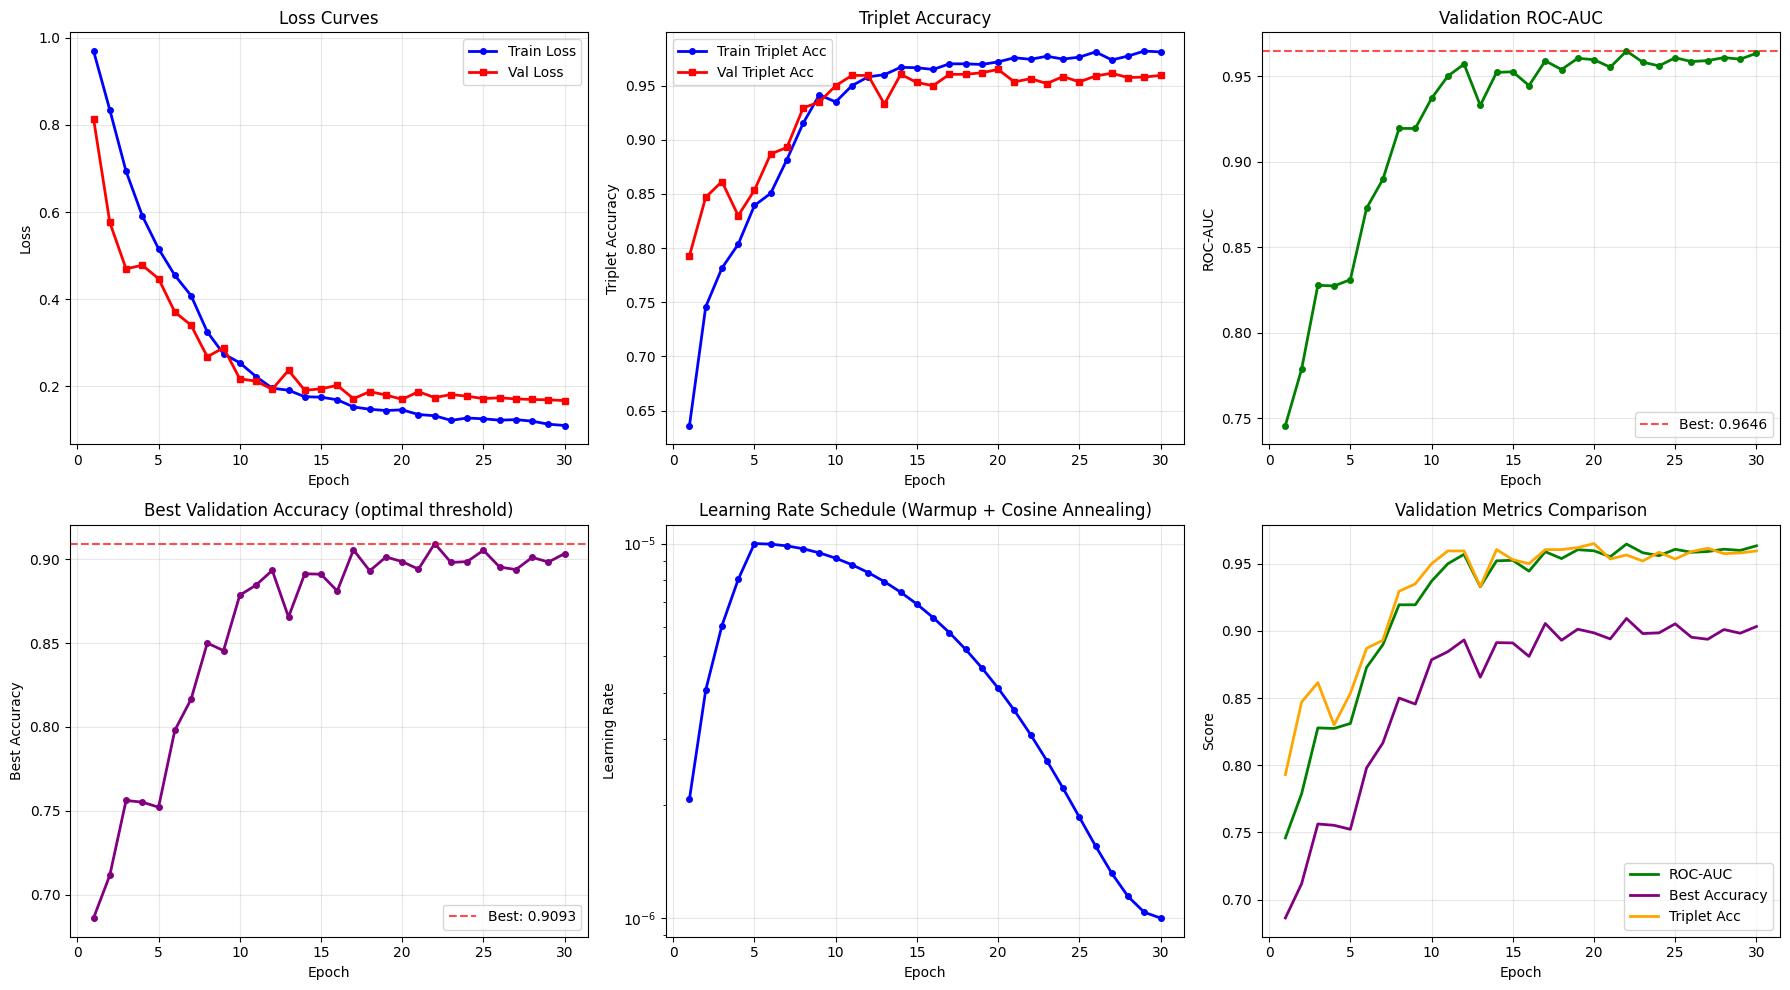

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

epochs = range(1, len(history_224['train_loss']) + 1)

# 1. Loss Curves
axes[0, 0].plot(epochs, history_224['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, history_224['val_loss'], 'r-s', label='Val Loss', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Triplet Accuracy
axes[0, 1].plot(epochs, history_224['train_triplet_accuracy'], 'b-o', label='Train Triplet Acc', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, history_224['val_triplet_accuracy'], 'r-s', label='Val Triplet Acc', linewidth=2, markersize=4)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Triplet Accuracy')
axes[0, 1].set_title('Triplet Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. ROC-AUC
axes[0, 2].plot(epochs, history_224['val_roc_auc'], 'g-o', linewidth=2, markersize=4)
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('ROC-AUC')
axes[0, 2].set_title('Validation ROC-AUC')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].axhline(y=max(history_224['val_roc_auc']), color='r', linestyle='--', alpha=0.7,
                   label=f"Best: {max(history_224['val_roc_auc']):.4f}")
axes[0, 2].legend()

# 4. Best Validation Accuracy
axes[1, 0].plot(epochs, history_224['val_best_accuracy'], 'purple', marker='o', linewidth=2, markersize=4)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Best Accuracy')
axes[1, 0].set_title('Best Validation Accuracy (optimal threshold)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=max(history_224['val_best_accuracy']), color='r', linestyle='--', alpha=0.7,
                   label=f"Best: {max(history_224['val_best_accuracy']):.4f}")
axes[1, 0].legend()

# 5. Learning Rate Schedule
axes[1, 1].plot(epochs, history_224['lr'], 'b-o', linewidth=2, markersize=4)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate Schedule (Warmup + Cosine Annealing)')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

# 6. Combined metrics
axes[1, 2].plot(epochs, history_224['val_roc_auc'], 'g-', label='ROC-AUC', linewidth=2)
axes[1, 2].plot(epochs, history_224['val_best_accuracy'], 'purple', label='Best Accuracy', linewidth=2)
axes[1, 2].plot(epochs, history_224['val_triplet_accuracy'], 'orange', label='Triplet Acc', linewidth=2)
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Score')
axes[1, 2].set_title('Validation Metrics Comparison')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics_224.png', dpi=150, bbox_inches='tight')
plt.show()

Now let's calculate results on test set

In [32]:
def calculate_eer(labels, scores):
    """
    Calculate Equal Error Rate (EER)
    """
    fpr, tpr, thresholds = roc_curve(labels, scores)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.absolute(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer


def evaluate_model_triplet(model, test_loader, device, val_threshold=None):
    """
    Evaluate CNNCrossViTTriplet model on test dataset.
    Uses Euclidean distance (consistent with Triplet Loss training).
    
    Args:
        model: CNNCrossViTTriplet model
        test_loader: DataLoader with test pairs (img1, img2, labels)
        device: cuda/cpu
        val_threshold: threshold from validation set (REQUIRED)
        checkpoint_path: optional path to load model checkpoint
    """

    model.eval()
    
    all_distances = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Testing"):
            # Unpack batch - assumes DataLoader returns (img1, img2, labels)
            img1, img2, labels = batch
            
            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.float().to(device)
            
            # Get embeddings using forward_one (since model expects triplet format)
            emb1 = model.forward_one(img1)
            emb2 = model.forward_one(img2)
            
            # Euclidean distance
            distances = torch.norm(emb1 - emb2, p=2, dim=1)
            
            all_distances.extend(distances.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    all_distances = np.array(all_distances)
    all_labels = np.array(all_labels)

    # 1. ROC-AUC (threshold-independent)
    # lower distance = more similar, so we use -distances for ROC
    roc_auc = roc_auc_score(all_labels, -all_distances)
    
    # 2. EER (threshold-independent)
    eer = calculate_eer(all_labels, -all_distances)
    
    # 3. Main accuracy with validation threshold
    main_predictions = (all_distances <= val_threshold).astype(int)
    main_accuracy = accuracy_score(all_labels, main_predictions)
    
    # 4. Confusion matrix with validation threshold
    cm = confusion_matrix(all_labels, main_predictions)
    tn, fp, fn, tp = cm.ravel()
    
    # 5. FAR, FRR with validation threshold
    far = fp / (fp + tn) if (fp + tn) > 0 else 0
    frr = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    # 6. Distance statistics
    pos_distances = all_distances[all_labels == 1]
    neg_distances = all_distances[all_labels == 0]
    
    #Results
    results = {
        'roc_auc': roc_auc,
        'eer': eer,
        'val_threshold': val_threshold,
        'main_accuracy': main_accuracy,
        'far': far,
        'frr': frr,
        'mean_distance_same': pos_distances.mean() if len(pos_distances) > 0 else 0,
        'std_distance_same': pos_distances.std() if len(pos_distances) > 0 else 0,
        'mean_distance_diff': neg_distances.mean() if len(neg_distances) > 0 else 0,
        'std_distance_diff': neg_distances.std() if len(neg_distances) > 0 else 0,
        'distance_gap': neg_distances.mean() - pos_distances.mean() if len(pos_distances) > 0 and len(neg_distances) > 0 else 0,
        'confusion_matrix': cm,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'num_samples': len(all_labels),
        'num_positive': int((all_labels == 1).sum()),
        'num_negative': int((all_labels == 0).sum()),
    }
    print(f"Samples: {results['num_samples']} (pos={results['num_positive']}, neg={results['num_negative']})")
    print(f"Threshold: {val_threshold:.4f}")
    print(f"ROC-AUC:           {results['roc_auc']:.4f}")
    print(f"EER:               {results['eer']:.4f}")
    print(f"Accuracy:          {results['main_accuracy']:.4f}")
    print(f"FAR:               {results['far']:.4f}")
    print(f"FRR:               {results['frr']:.4f}")
    print(f"Same author:       {results['mean_distance_same']:.4f} ± {results['std_distance_same']:.4f}")
    print(f"Diff authors:      {results['mean_distance_diff']:.4f} ± {results['std_distance_diff']:.4f}")
    print(f"Gap:               {results['distance_gap']:.4f}")
    print(f"TN={tn:5d}  FP={fp:5d}")
    print(f"FN={fn:5d}  TP={tp:5d}")
    
    return results

In [33]:
evaluate_model_triplet(model, test_loader, device, val_threshold=0.720)

NameError: name 'model' is not defined